# Diabetes Prediction Models

## Imports

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv('dataset/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Preprocessing

General Information About the Dataset

In [3]:
df.shape

(768, 9)

In [4]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.columns.values

<StringArray>
[             'Pregnancies',                  'Glucose',
            'BloodPressure',            'SkinThickness',
                  'Insulin',                      'BMI',
 'DiabetesPedigreeFunction',                      'Age',
                  'Outcome']
Length: 9, dtype: str

In [8]:
df.groupby('Outcome').size()

Outcome
0    500
1    268
dtype: int64

## Visualizations

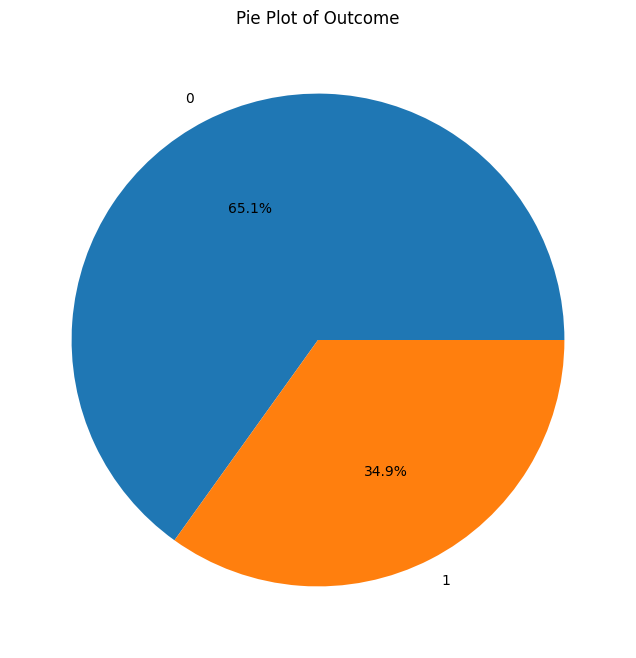

In [9]:
category_counts = df['Outcome'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%')
plt.title('Pie Plot of Outcome')
plt.show()

In [10]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

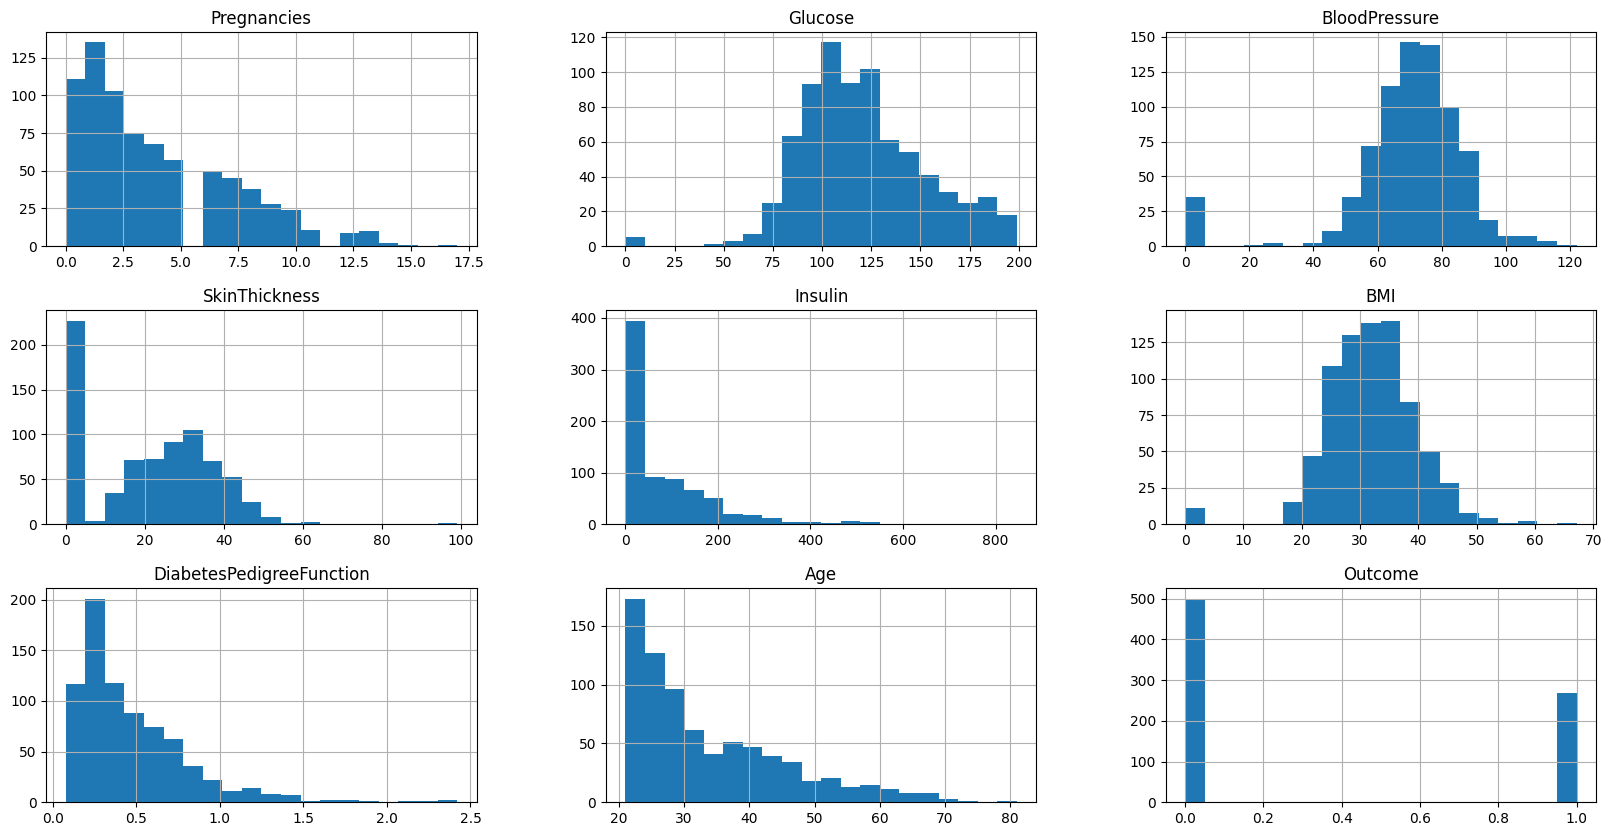

In [11]:
df.hist(bins=20, figsize=(20, 10))
plt.show()

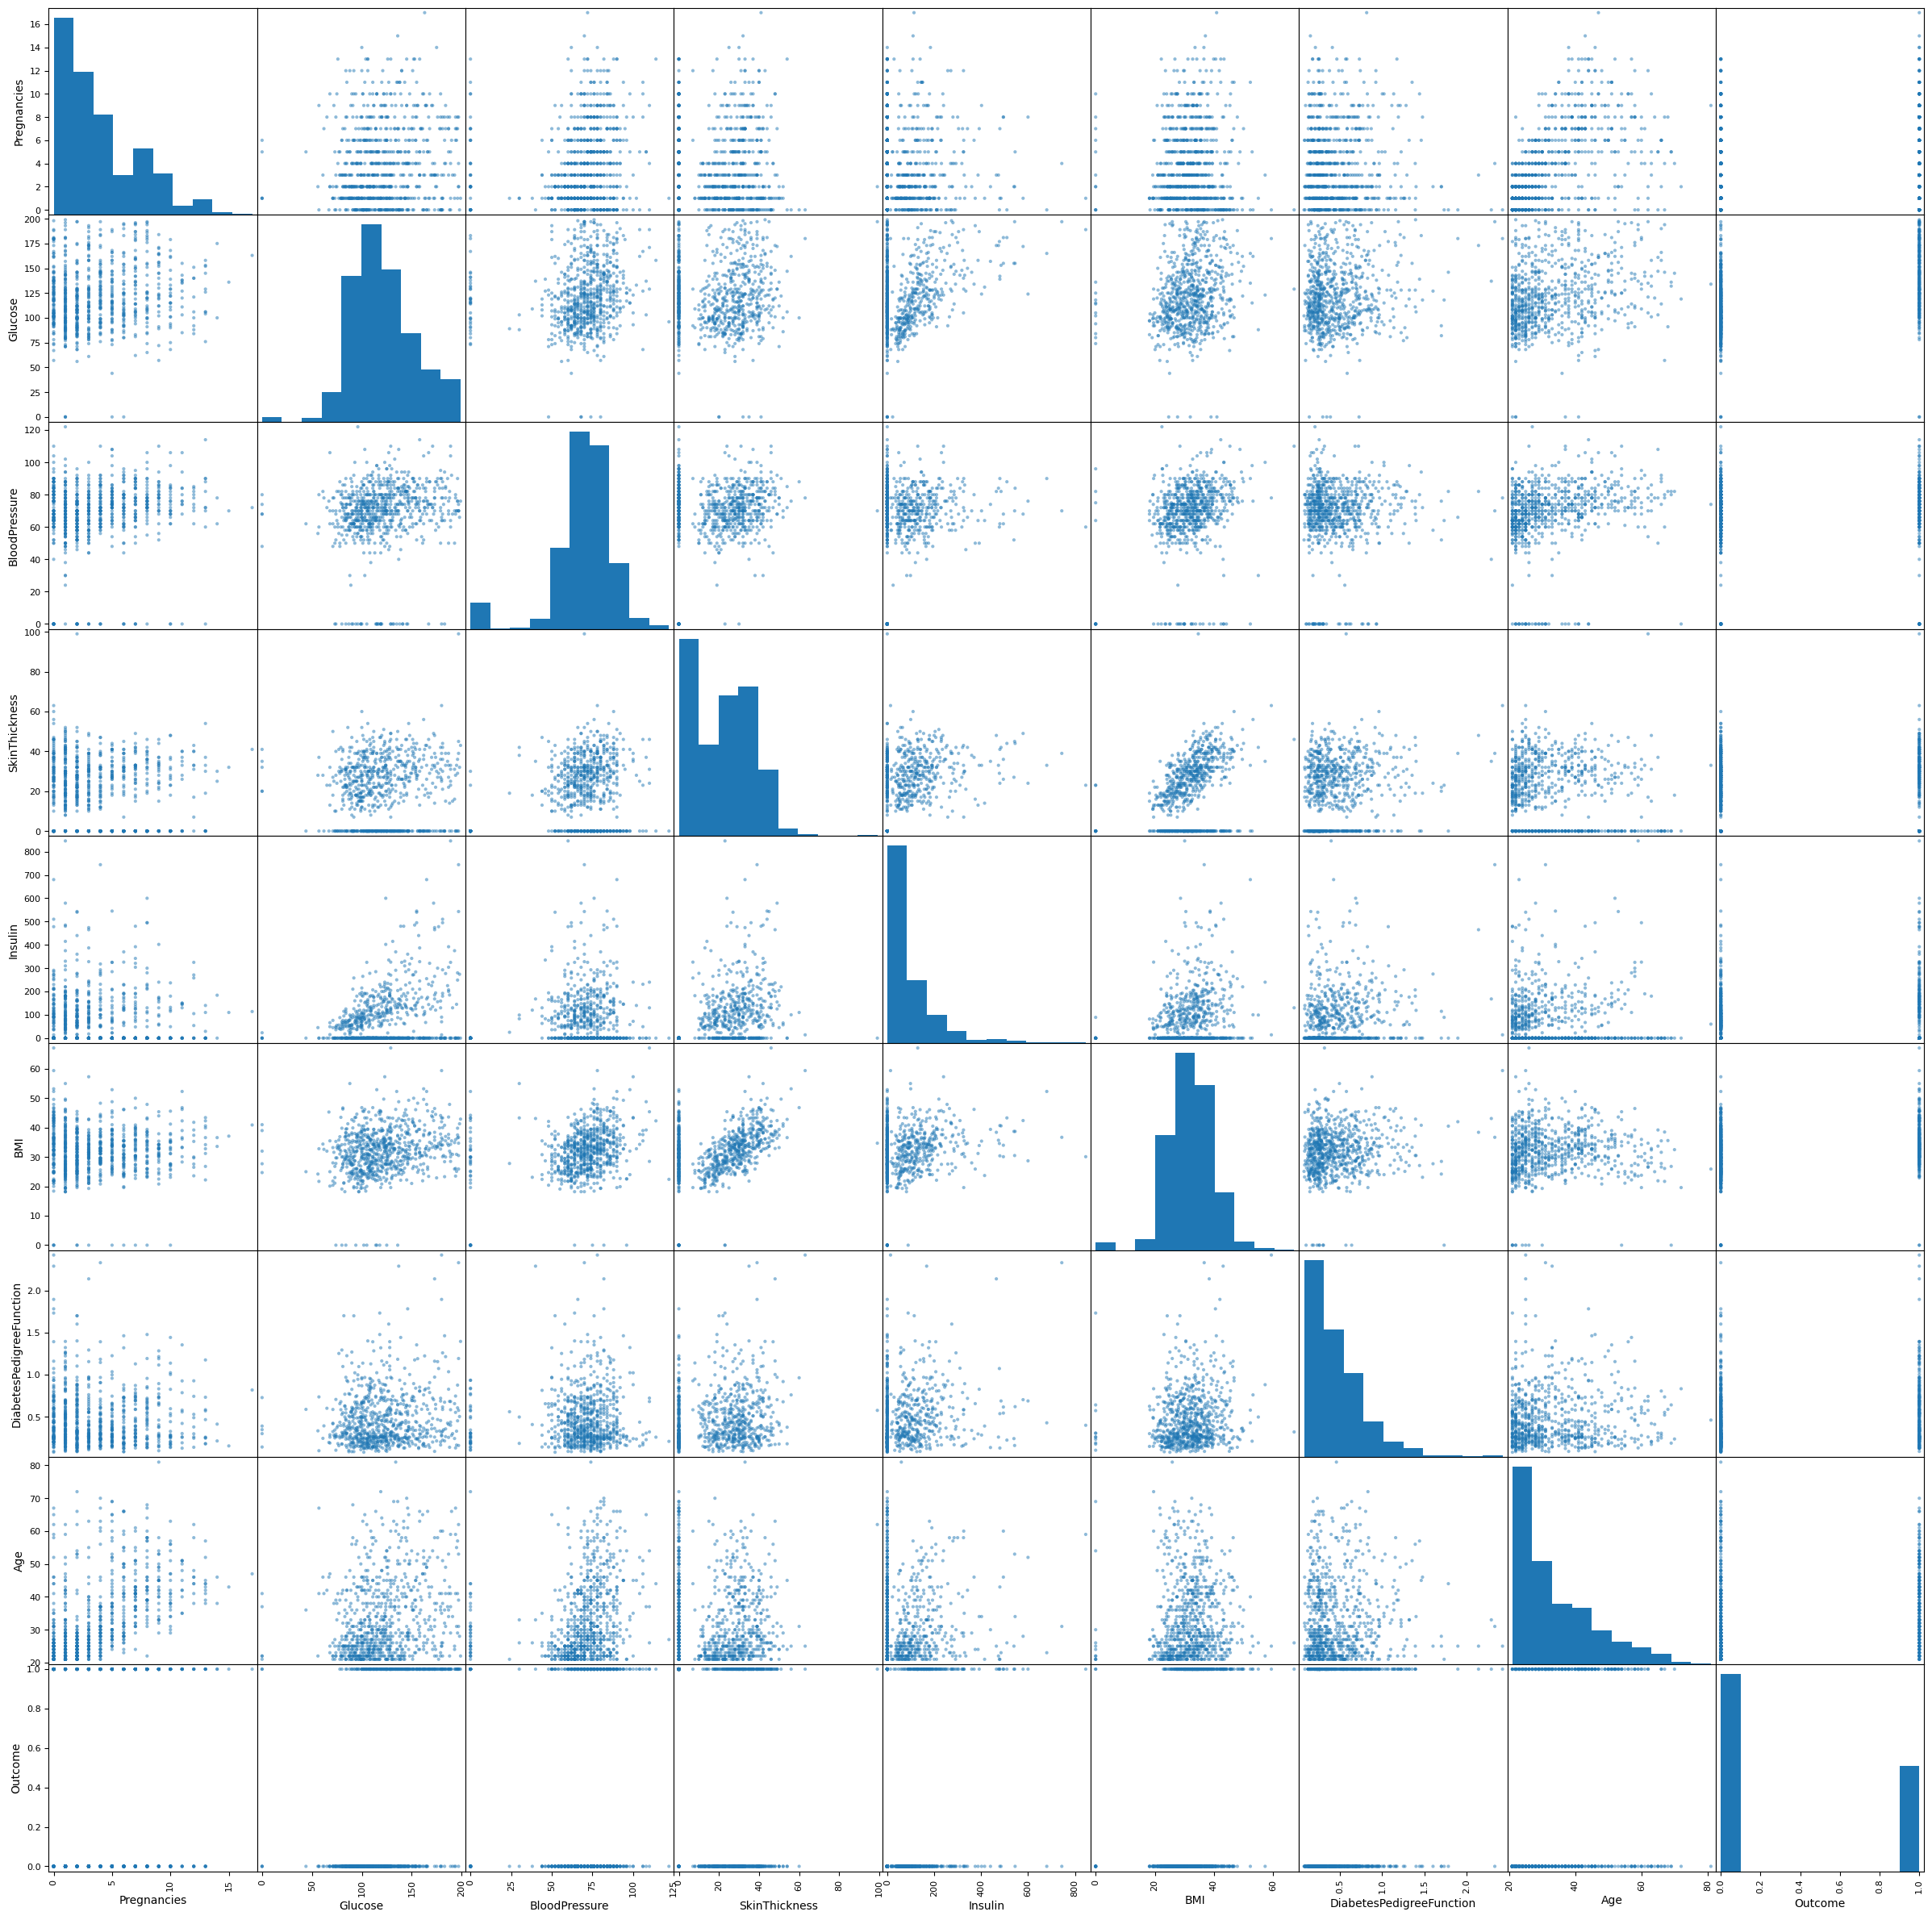

In [12]:
scatter_matrix(df, figsize=(30, 30), diagonal='hist', alpha=0.5)
plt.show()

## Data Cleaning

In [13]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [14]:
df.drop_duplicates(inplace=True)

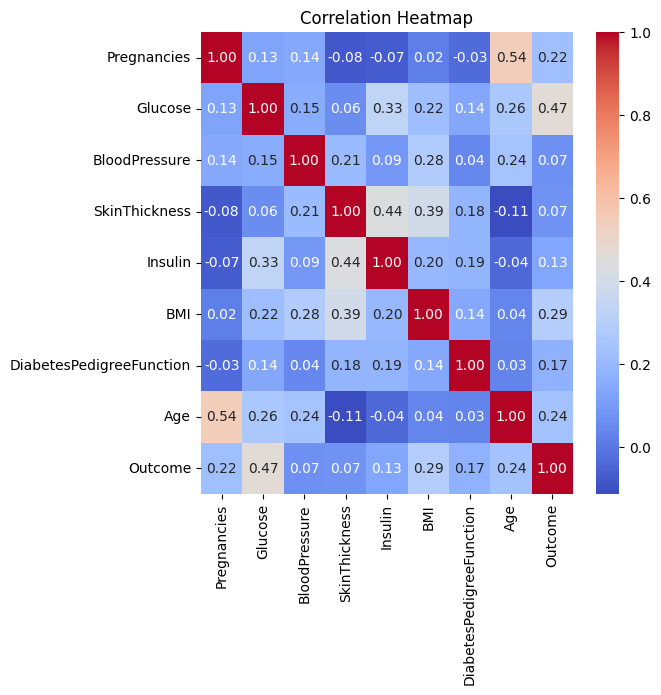

In [15]:
plt.figure(figsize=(6, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Outlier Handling

Some columns use 0 as a placeholder for missing values. We replace these with the group median, then clip remaining outliers using IQR.

In [16]:
print('total : ', df[df.BloodPressure == 0].shape[0])
df[df.BloodPressure == 0].groupby('Outcome')['Age'].count()

total :  35


Outcome
0    19
1    16
Name: Age, dtype: int64

In [17]:
print('total : ', df[df.Glucose == 0].shape[0])
df[df.Glucose == 0].groupby('Outcome')['Age'].count()

total :  5


Outcome
0    3
1    2
Name: Age, dtype: int64

In [18]:
print('total : ', df[df.SkinThickness == 0].shape[0])
df[df.SkinThickness == 0].groupby('Outcome')['Age'].count()

total :  227


Outcome
0    139
1     88
Name: Age, dtype: int64

In [19]:
print('total : ', df[df.BMI == 0].shape[0])
df[df.BMI == 0].groupby('Outcome')['Age'].count()

total :  11


Outcome
0    9
1    2
Name: Age, dtype: int64

In [20]:
print('total : ', df[df.Insulin == 0].shape[0])
df[df.Insulin == 0].groupby('Outcome')['Age'].count()

total :  374


Outcome
0    236
1    138
Name: Age, dtype: int64

In [21]:
# Replace impossible zeros with NaN then fill with group median
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_mod = df.copy()

for col in zero_cols:
    df_mod[col] = df_mod[col].replace(0, np.nan)
    df_mod[col] = df_mod.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

print(df_mod.shape)

(768, 9)


In [22]:
# Clip outliers using IQR — no rows dropped
numeric_cols = [c for c in df_mod.columns if c != 'Outcome']

for col in numeric_cols:
    Q1 = df_mod[col].quantile(0.25)
    Q3 = df_mod[col].quantile(0.75)
    IQR = Q3 - Q1
    df_mod[col] = df_mod[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

print(df_mod.shape)

(768, 9)


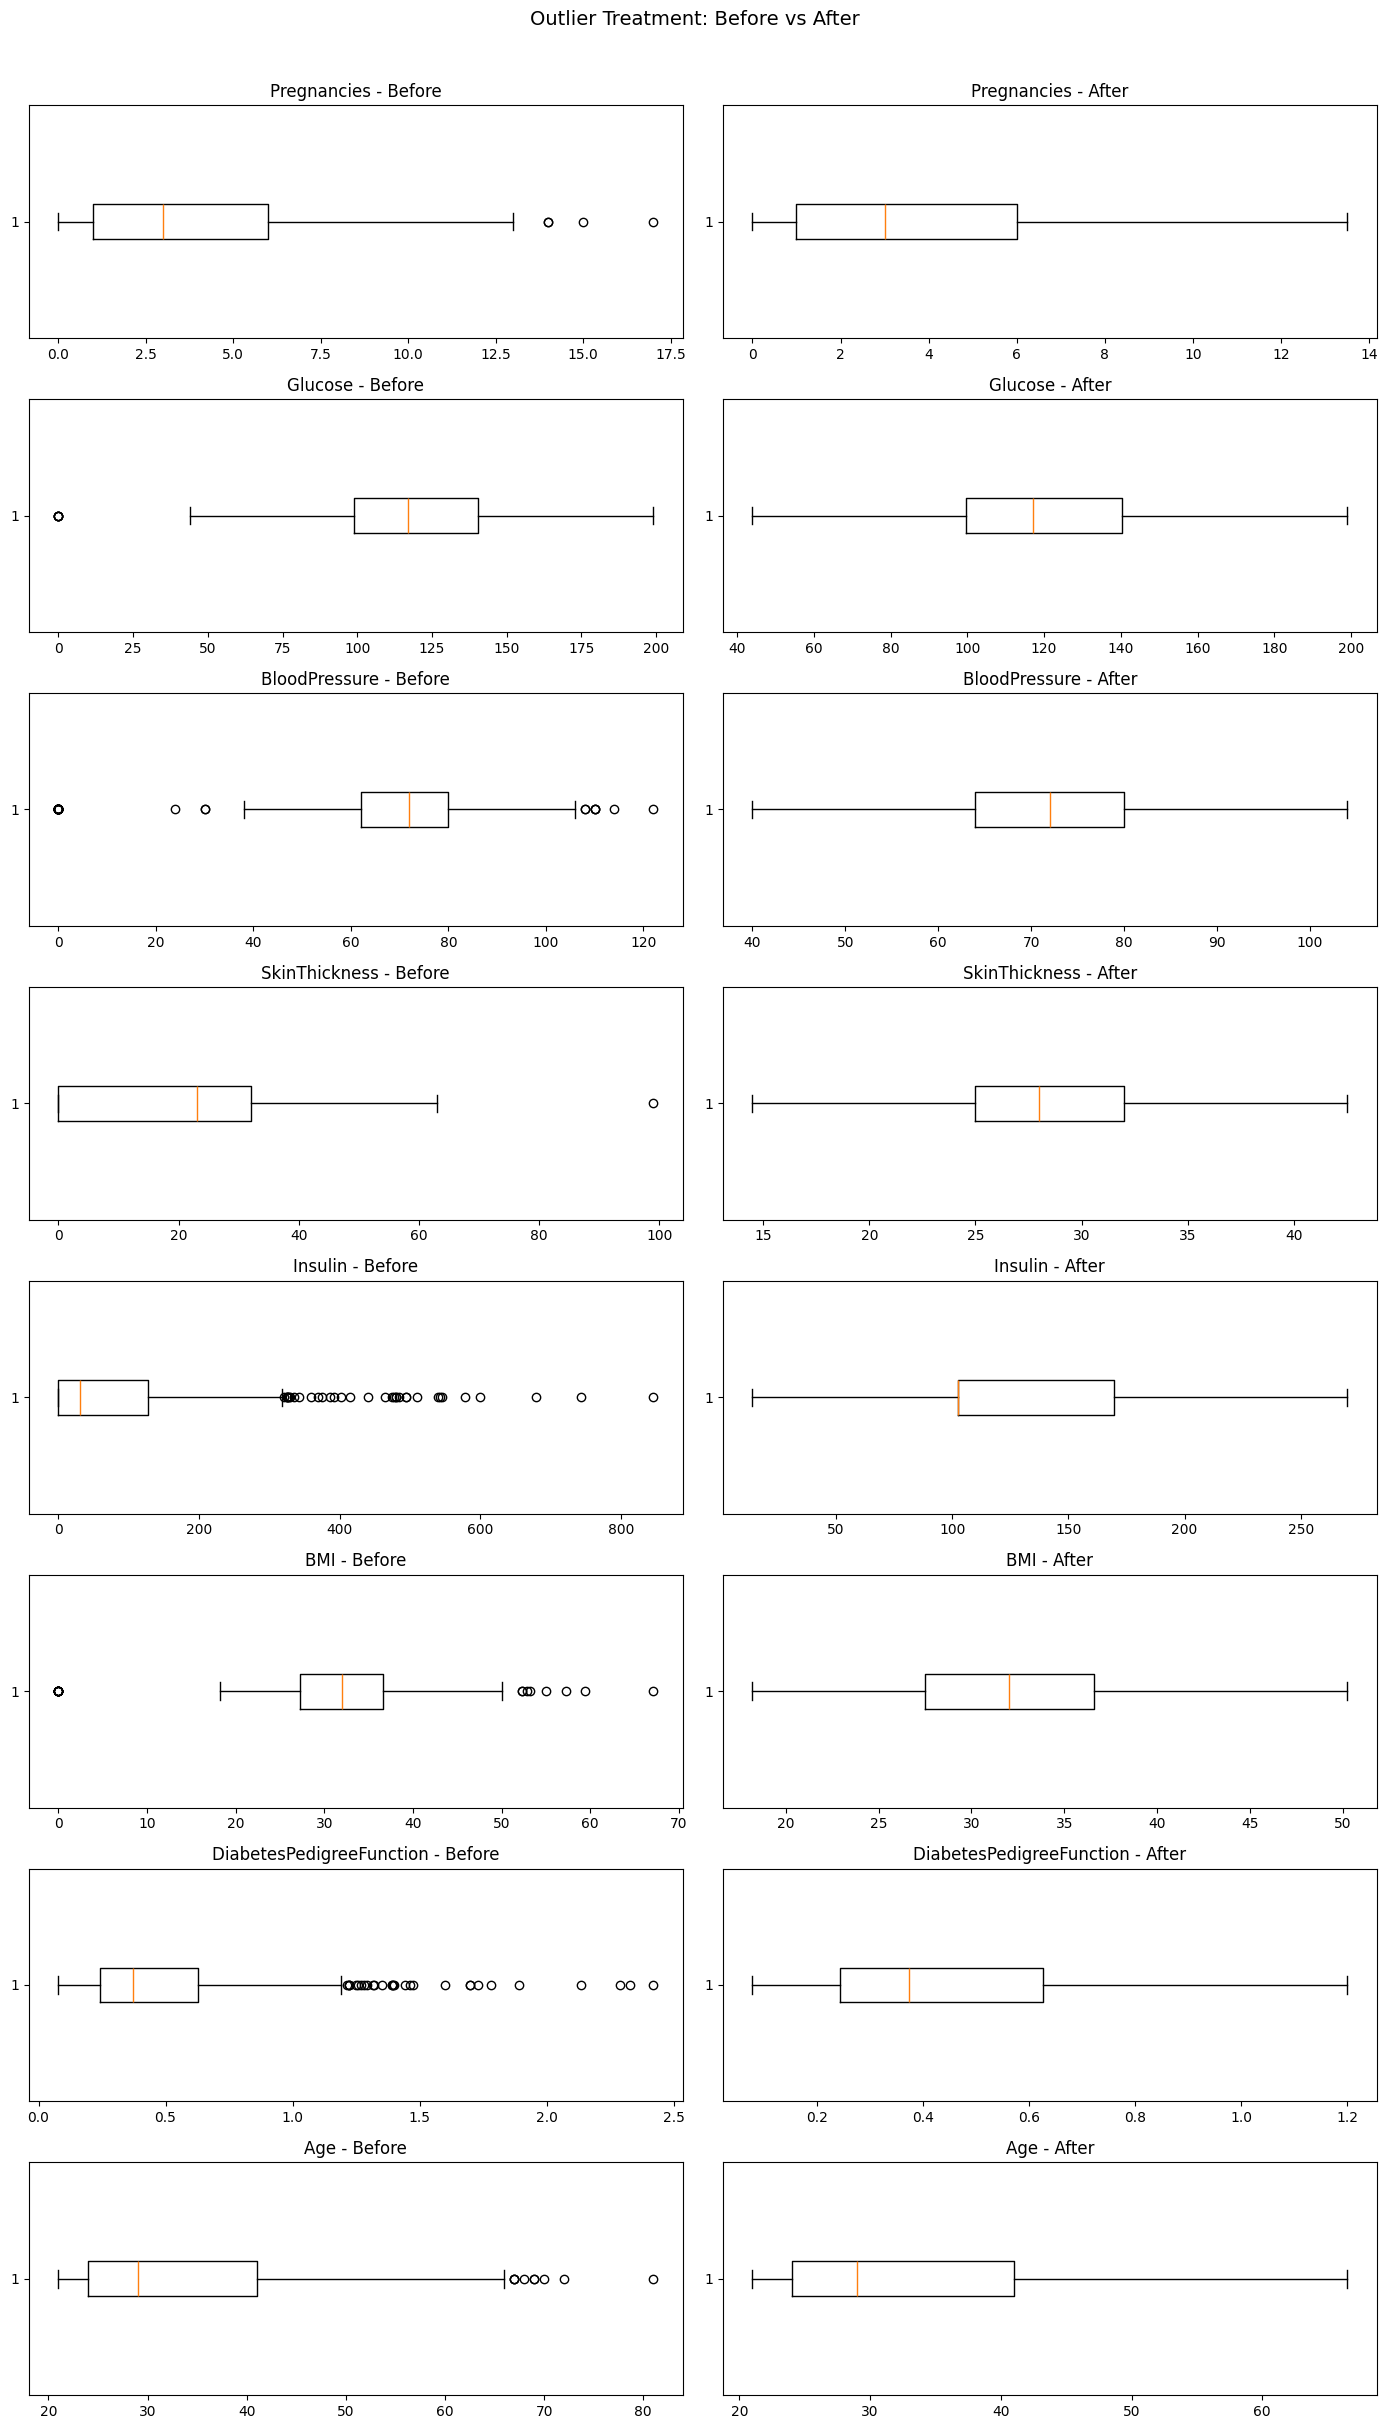

In [23]:
# Before vs after box plots
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, len(numeric_cols) * 3))

for i, col in enumerate(numeric_cols):
    axes[i, 0].boxplot(df[col].dropna(), vert=False)
    axes[i, 0].set_title(f'{col} - Before')
    axes[i, 1].boxplot(df_mod[col].dropna(), vert=False)
    axes[i, 1].set_title(f'{col} - After')

plt.suptitle('Outlier Treatment: Before vs After', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Standardization

In [24]:
scaler = MinMaxScaler()
df_mod[numeric_cols] = scaler.fit_transform(df_mod[numeric_cols])
print(df_mod)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0       0.444444  0.670968        0.50000       0.732143  0.607422  0.480499   
1       0.074074  0.264516        0.40625       0.517857  0.345703  0.262090   
2       0.592593  0.896774        0.37500       0.625000  0.607422  0.159126   
3       0.074074  0.290323        0.40625       0.303571  0.312500  0.308892   
4       0.000000  0.600000        0.00000       0.732143  0.601562  0.776911   
..           ...       ...            ...            ...       ...       ...   
763     0.740741  0.367742        0.56250       1.000000  0.648438  0.458658   
764     0.148148  0.503226        0.46875       0.446429  0.345703  0.580343   
765     0.370370  0.496774        0.50000       0.303571  0.382812  0.249610   
766     0.074074  0.529032        0.31250       0.625000  0.607422  0.371295   
767     0.074074  0.316129        0.46875       0.589286  0.345703  0.380655   

     DiabetesPedigreeFunction       Age

In [ ]:
df_mod.to_csv("dataset/cleaned_dataset.csv", index=False)

## Train / Test Split

In [31]:
diabetes_df = pd.read_csv('data/cleaned_dataset.csv')

X = diabetes_df.drop('Outcome', axis=1)
y = diabetes_df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic Regression

In [32]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

accuracy_LR = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy_LR:.2f}')
print(f'Precision: {precision_score(y_test, y_pred):.2f}')
print(f'F1-score: {f1_score(y_test, y_pred):.2f}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy: 0.81
Precision: 0.74
F1-score: 0.73
Confusion Matrix:
 [[85 14]
 [15 40]]


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85        99
           1       0.74      0.73      0.73        55

    accuracy                           0.81       154
   macro avg       0.80      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154



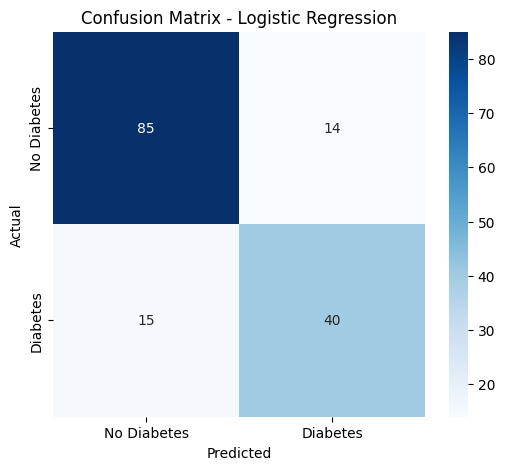

In [34]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Decision Tree

In [35]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

accuracy_DT = accuracy_score(y_test, y_pred)
print(f'Decision Tree Accuracy: {accuracy_DT:.2f}')
print(f'Precision: {precision_score(y_test, y_pred):.2f}')
print(f'Recall: {recall_score(y_test, y_pred):.2f}')
print(f'F1-score: {f1_score(y_test, y_pred):.2f}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Decision Tree Accuracy: 0.82
Precision: 0.73
Recall: 0.80
F1-score: 0.77
Confusion Matrix:
 [[83 16]
 [11 44]]


In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86        99
           1       0.73      0.80      0.77        55

    accuracy                           0.82       154
   macro avg       0.81      0.82      0.81       154
weighted avg       0.83      0.82      0.83       154



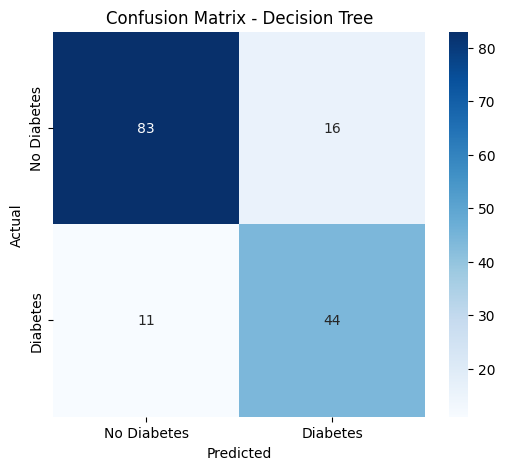

In [37]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

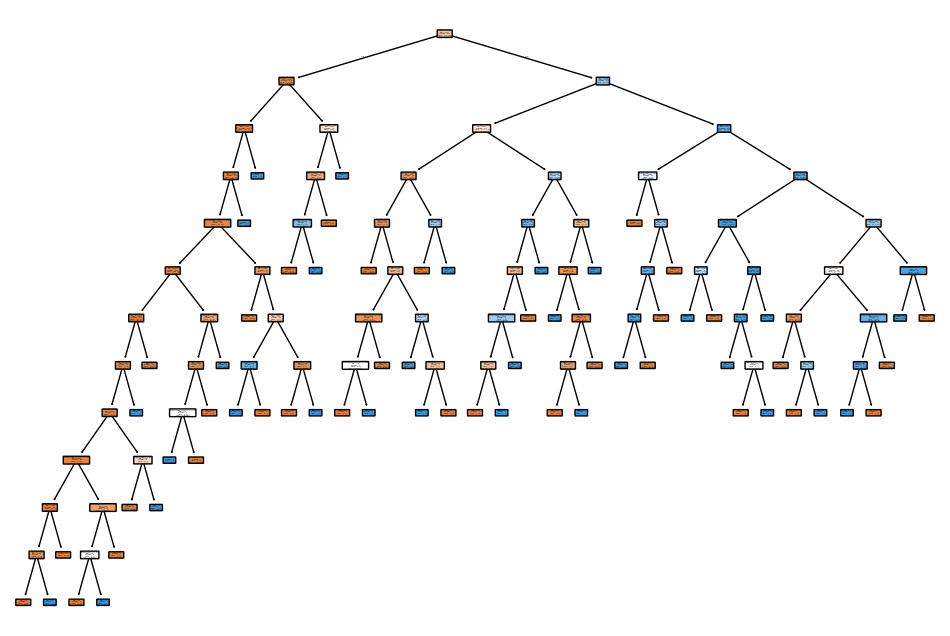

In [38]:
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, rounded=True)
plt.show()

## Gradient Boosting

In [39]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

accuracy_GB = accuracy_score(y_test, y_pred)
print(f'Gradient Boosting Accuracy: {accuracy_GB:.2f}')
print(f'Precision: {precision_score(y_test, y_pred):.2f}')
print(f'Recall: {recall_score(y_test, y_pred):.2f}')
print(f'F1-score: {f1_score(y_test, y_pred):.2f}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Gradient Boosting Accuracy: 0.87
Precision: 0.81
Recall: 0.84
F1-score: 0.82
Confusion Matrix:
 [[88 11]
 [ 9 46]]


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90        99
           1       0.81      0.84      0.82        55

    accuracy                           0.87       154
   macro avg       0.86      0.86      0.86       154
weighted avg       0.87      0.87      0.87       154



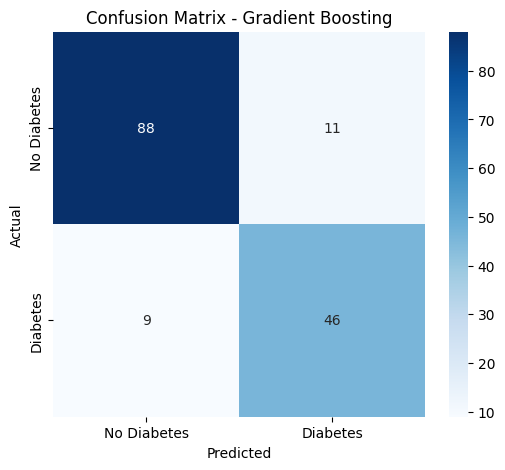

In [41]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Random Forest

In [42]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

accuracy_RF = accuracy_score(y_test, y_pred)
print(f'Random Forest Accuracy: {accuracy_RF:.2f}')
print(f'Precision: {precision_score(y_test, y_pred):.2f}')
print(f'Recall: {recall_score(y_test, y_pred):.2f}')
print(f'F1-score: {f1_score(y_test, y_pred):.2f}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Random Forest Accuracy: 0.87
Precision: 0.80
Recall: 0.85
F1-score: 0.82
Confusion Matrix:
 [[87 12]
 [ 8 47]]


In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        99
           1       0.80      0.85      0.82        55

    accuracy                           0.87       154
   macro avg       0.86      0.87      0.86       154
weighted avg       0.87      0.87      0.87       154



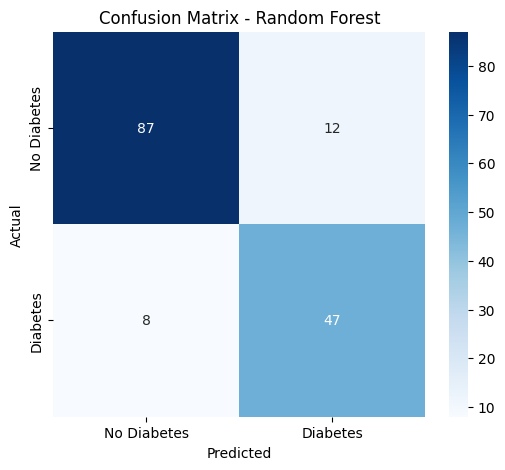

In [44]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Support Vector Machine

In [45]:
svm = SVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

accuracy_SVM = accuracy_score(y_test, y_pred)
print(f'SVM Accuracy: {accuracy_SVM:.2f}')
print(f'Precision: {precision_score(y_test, y_pred):.2f}')
print(f'Recall: {recall_score(y_test, y_pred):.2f}')
print(f'F1-score: {f1_score(y_test, y_pred):.2f}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

SVM Accuracy: 0.88
Precision: 0.80
Recall: 0.87
F1-score: 0.83
Confusion Matrix:
 [[87 12]
 [ 7 48]]


In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90        99
           1       0.80      0.87      0.83        55

    accuracy                           0.88       154
   macro avg       0.86      0.88      0.87       154
weighted avg       0.88      0.88      0.88       154



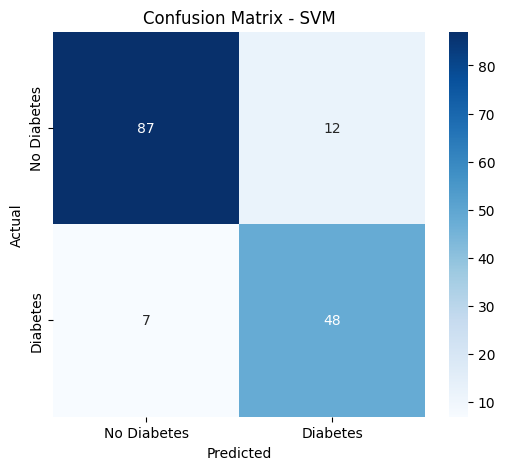

In [47]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Neural Network

In [48]:
nn = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=500, random_state=42)
nn.fit(X_train, y_train)
y_pred = nn.predict(X_test)

accuracy_NN = accuracy_score(y_test, y_pred)
print(f'Neural Network Accuracy: {accuracy_NN:.2f}')
print(f'Precision: {precision_score(y_test, y_pred, zero_division=1):.2f}')
print(f'Recall: {recall_score(y_test, y_pred, zero_division=1):.2f}')
print(f'F1-score: {f1_score(y_test, y_pred, zero_division=1):.2f}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Neural Network Accuracy: 0.82
Precision: 0.76
Recall: 0.71
F1-score: 0.74
Confusion Matrix:
 [[87 12]
 [16 39]]


In [49]:
print(classification_report(y_test, y_pred, zero_division=1))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        99
           1       0.76      0.71      0.74        55

    accuracy                           0.82       154
   macro avg       0.80      0.79      0.80       154
weighted avg       0.82      0.82      0.82       154



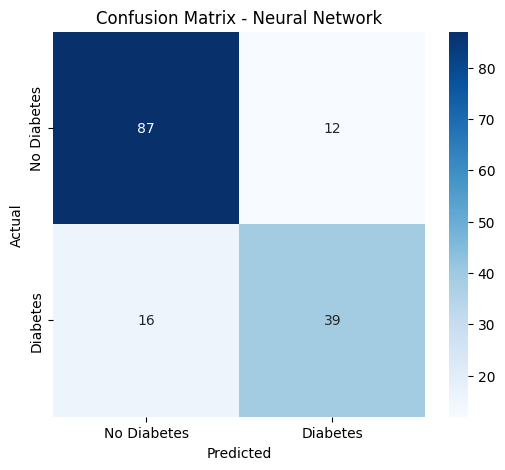

In [50]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Comparison

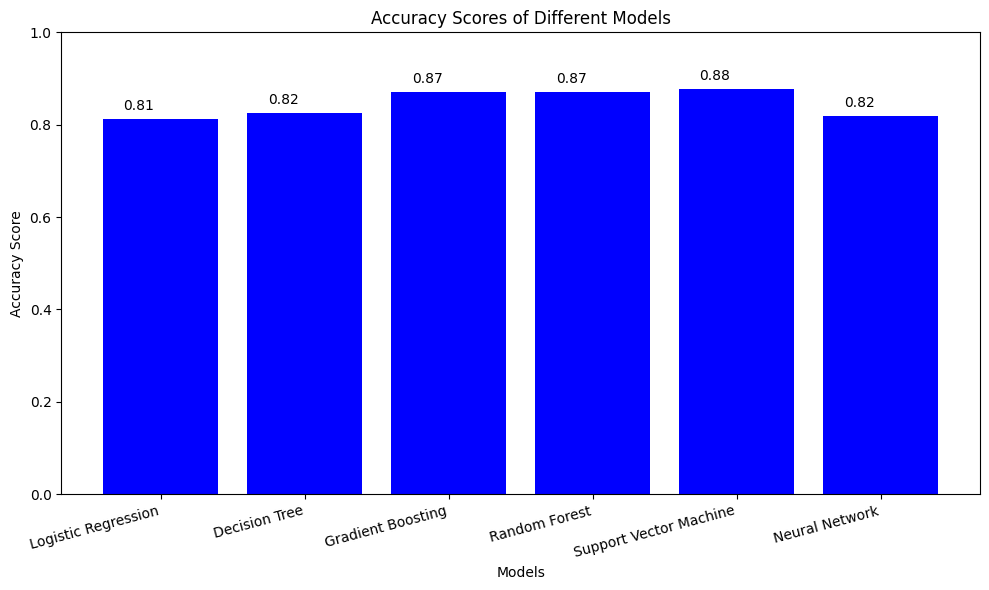

In [51]:
models = ['Logistic Regression', 'Decision Tree', 'Gradient Boosting', 'Random Forest', 'Support Vector Machine', 'Neural Network']
accuracy_scores = [accuracy_LR, accuracy_DT, accuracy_GB, accuracy_RF, accuracy_SVM, accuracy_NN]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy_scores, color='blue')
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Scores of Different Models')
plt.ylim(0, 1)

for bar, accuracy in zip(bars, accuracy_scores):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.15, bar.get_height() + 0.02, f'{accuracy:.2f}', ha='center', color='black')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


Logistic Regression Evaluation Metrics:
Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85        99
           1       0.74      0.73      0.73        55

    accuracy                           0.81       154
   macro avg       0.80      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154



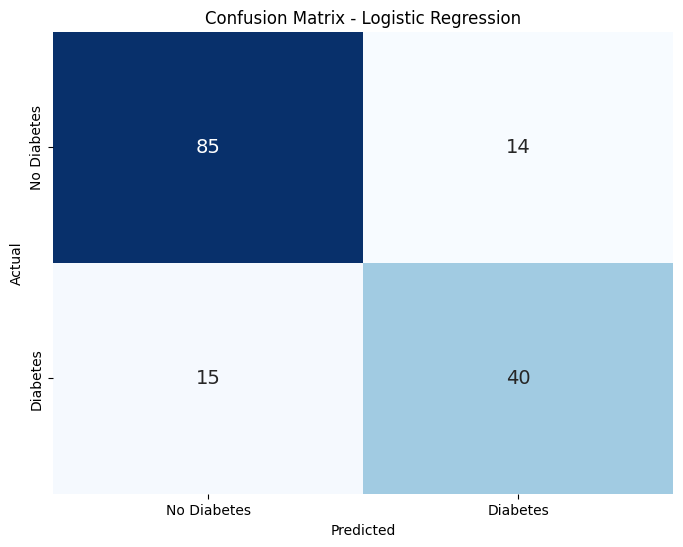


Decision Tree Evaluation Metrics:
Accuracy: 0.82
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        99
           1       0.73      0.80      0.77        55

    accuracy                           0.82       154
   macro avg       0.81      0.82      0.81       154
weighted avg       0.83      0.82      0.83       154



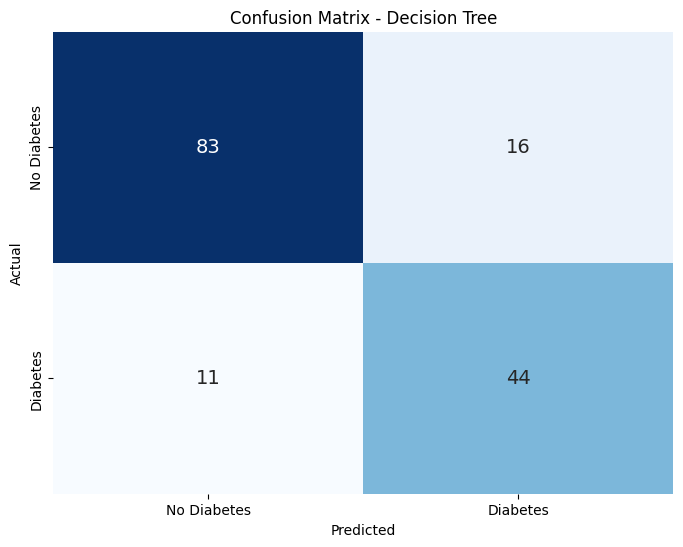


Gradient Boosting Evaluation Metrics:
Accuracy: 0.87
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        99
           1       0.81      0.84      0.82        55

    accuracy                           0.87       154
   macro avg       0.86      0.86      0.86       154
weighted avg       0.87      0.87      0.87       154



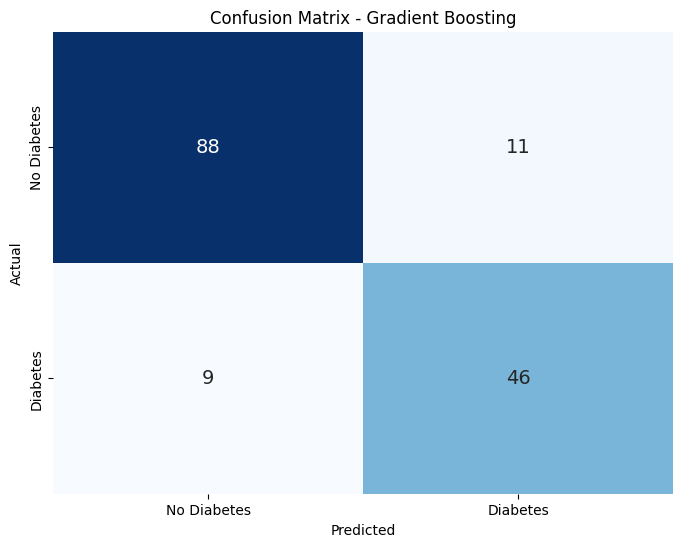


Random Forest Evaluation Metrics:
Accuracy: 0.87
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        99
           1       0.80      0.85      0.82        55

    accuracy                           0.87       154
   macro avg       0.86      0.87      0.86       154
weighted avg       0.87      0.87      0.87       154



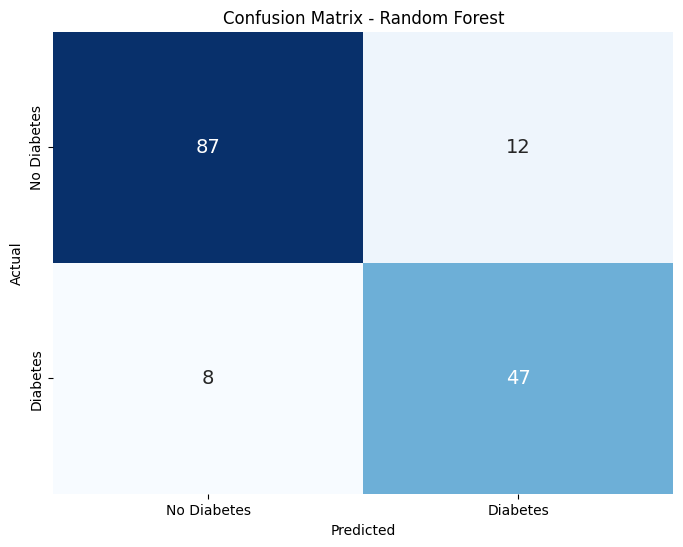


Support Vector Machine Evaluation Metrics:
Accuracy: 0.88
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        99
           1       0.80      0.87      0.83        55

    accuracy                           0.88       154
   macro avg       0.86      0.88      0.87       154
weighted avg       0.88      0.88      0.88       154



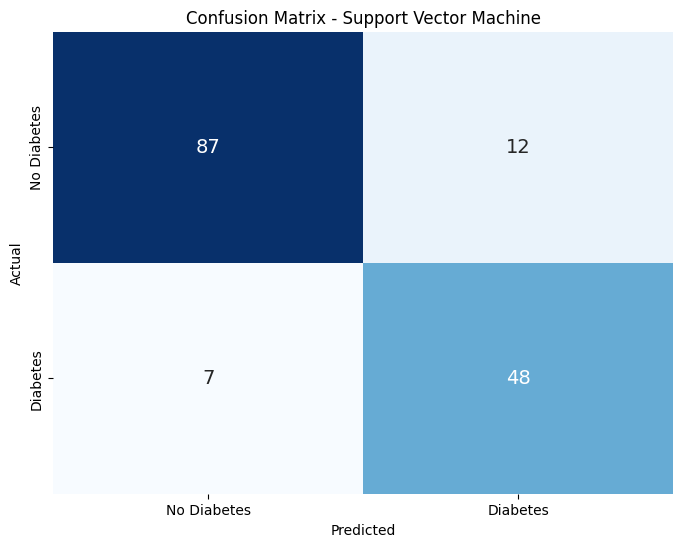


Neural Network Evaluation Metrics:
Accuracy: 0.82
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        99
           1       0.76      0.71      0.74        55

    accuracy                           0.82       154
   macro avg       0.80      0.79      0.80       154
weighted avg       0.82      0.82      0.82       154



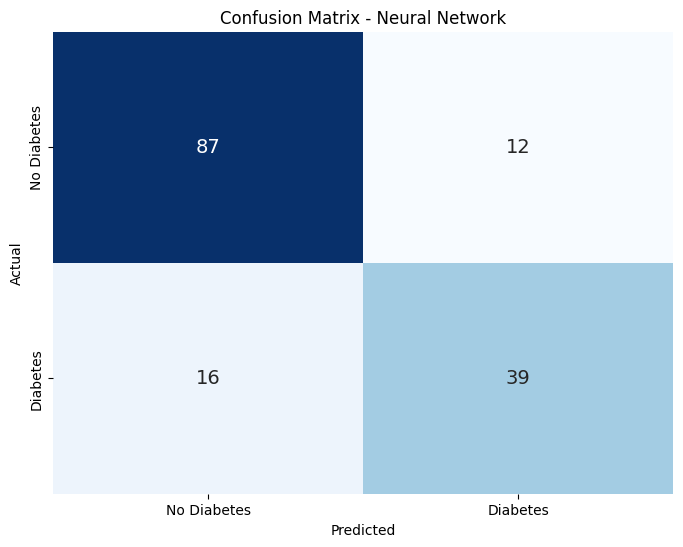

In [52]:
all_models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=500, random_state=42)
}

for name, model in all_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f'\n{name} Evaluation Metrics:')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
    print(f'Classification Report:\n{classification_report(y_test, y_pred)}')

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                annot_kws={'size': 14},
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()